In [1]:
try:
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import matplotlib.gridspec as gridspec
    from matplotlib.patches import Ellipse
except ImportError as e:
    print(f"Error importing libraries: {e}")
    print("Matplotlib and NumPy are required to generate the plots.")

try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    print("SciencePlots is not installed. Using default Matplotlib style (plots will look different).")

from pathlib import Path

In [2]:
root = Path.cwd() / "../.."
iceIh_path = root / "data" / "iceIh"

if iceIh_path.exists():
    iceIh_10perc_data = np.load(root / "data" / "iceIh" / "iceIh_10perc_rdf.npy", allow_pickle=True).item()
else:
    raise FileNotFoundError(f"Data directory {iceIh_path} does not exist. Please ensure the data files are in the correct location.")

In [3]:
r = iceIh_10perc_data["r"]
times = iceIh_10perc_data["times"]
plot_indices = iceIh_10perc_data["plot_indices"]
times_to_plot = iceIh_10perc_data["times_to_plot"]
meanOO = iceIh_10perc_data["meanOO"]
errOO = iceIh_10perc_data["errOO"]
deltaR1_OO = iceIh_10perc_data["deltaR1_OO"]
deltaI2_OO = iceIh_10perc_data["deltaI2_OO"]
R1_all_err = iceIh_10perc_data["R1_all_err"]
I2_all_err = iceIh_10perc_data["I2_all_err"]
A1_OO = iceIh_10perc_data["A1_OO"]
B1_OO = iceIh_10perc_data["B1_OO"]
A2_OO = iceIh_10perc_data["A2_OO"]
B2_OO = iceIh_10perc_data["B2_OO"]

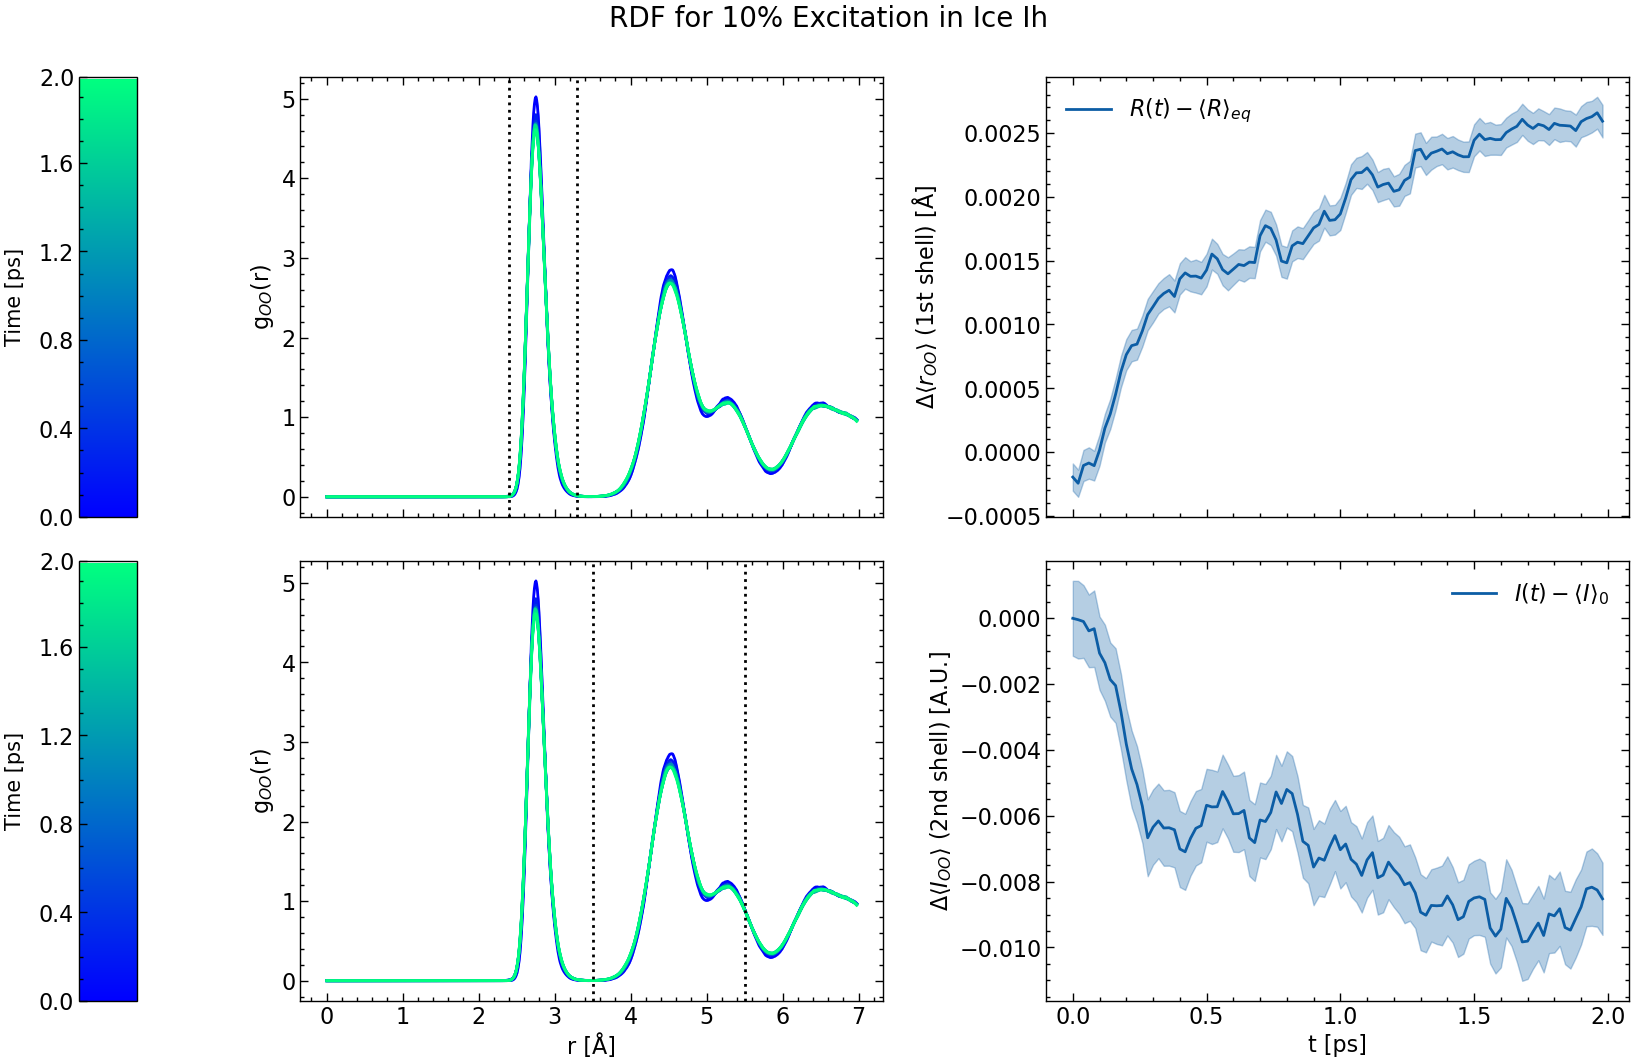

In [4]:
label_fontsize = 15
cmap = plt.get_cmap("winter")
norm = mpl.colors.Normalize(vmin=min(times_to_plot), vmax=max(times_to_plot))

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[0.1, 1, 1], wspace=0.4, hspace=0.1)

ax_bl = fig.add_subplot(gs[1, 1])
ax_br = fig.add_subplot(gs[1, 2])
ax_tl = fig.add_subplot(gs[0, 1], sharex=ax_bl)
ax_tr = fig.add_subplot(gs[0, 2], sharex=ax_br)
cax_t = fig.add_subplot(gs[0, 0])
cax_b = fig.add_subplot(gs[1, 0])

ax_tr.tick_params(axis="x", labelbottom=False)
ax_tl.tick_params(axis="x", labelbottom=False)

for idx, t in zip(plot_indices, times_to_plot):
    current_color = cmap(norm(t))
    ax_tl.plot(r[:-2], meanOO[idx][:-2], color=current_color)
    ax_tl.fill_between(
        r[:-2],
        meanOO[idx][:-2] - R1_all_err[idx],
        meanOO[idx][:-2] + R1_all_err[idx],
        color=current_color,
        alpha=0.3
    )

ax_tl.axvline(A1_OO, ls=":", color="k")
ax_tl.axvline(B1_OO, ls=":", color="k")
ax_tl.set_ylabel("g$_{OO}$(r)")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar_t = fig.colorbar(sm, cax=cax_t, orientation="vertical")
cbar_t.set_label("Time [ps]", fontsize=label_fontsize, labelpad=10)
cbar_b = fig.colorbar(sm, cax=cax_b, orientation="vertical")
cbar_b.set_label("Time [ps]", fontsize=label_fontsize, labelpad=10)

ax_tr.plot(times, deltaR1_OO, label=r"$R(t) - \langle R \rangle_{eq}$", color="C0")
ax_tr.fill_between(times, deltaR1_OO - R1_all_err, deltaR1_OO + R1_all_err, color="C0", alpha=0.3)
ax_tr.set_ylabel(r"$\Delta \langle r_{OO} \rangle$ (1st shell) [Å]")
ax_tr.legend()

ax_br.plot(times, deltaI2_OO, label=r"$I(t) - \langle I \rangle_0$", color="C0")
ax_br.fill_between(times, deltaI2_OO - I2_all_err, deltaI2_OO + I2_all_err, color="C0", alpha=0.3)
ax_br.set_ylabel(r"$\Delta \langle I_{OO} \rangle$ (2nd shell) [A.U.]")
ax_br.set_xlabel("t [ps]")
ax_br.legend()

for idx, t in zip(plot_indices, times_to_plot):
    current_color = cmap(norm(t))
    ax_bl.plot(r[:-2], meanOO[idx][:-2], color=current_color)
    ax_bl.fill_between(
        r[:-2],
        meanOO[idx][:-2] - I2_all_err[idx],
        meanOO[idx][:-2] + I2_all_err[idx],
        color=current_color,
        alpha=0.3
    )

ax_bl.axvline(A2_OO, ls=":", color="k")
ax_bl.axvline(B2_OO, ls=":", color="k")
ax_bl.set_ylabel("g$_{OO}$(r)")
ax_bl.set_xlabel("r [Å]")

for cbar in (cbar_t, cbar_b):
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.yaxis.set_ticks_position("left")
    cbar.ax.yaxis.set_ticks([0.0, 0.4, 0.8, 1.2, 1.6, 1.99])
    cbar.ax.yaxis.set_ticklabels(["0.0", "0.4", "0.8", "1.2", "1.6", "2.0"])

fig.suptitle('RDF for 10% Excitation in Ice Ih', fontsize=20, y=0.94)

plt.savefig(root / 'plots' / 'iceIh' / 'iceIh_10perc_rdf.png', dpi=300)
plt.show()